In [67]:
import jupyter_black
import torch
import numpy as np
import torchvision
import os
import yaml
import random
from tqdm.auto import tqdm
from torch import nn
import matplotlib.pyplot as plt
from pathlib import Path
from torchvision import datasets, transforms
from PIL import Image
from torch.utils.data import Dataset, DataLoader

jupyter_black.load()

In [2]:
device = "mps" if torch.backends.mps.is_available() else "CPU"
device

'mps'

# Health/disease detection

## Getting the data 

In [3]:
# import kagglehub

# path = kagglehub.dataset_download("andresmgs/plantdec")
# print("Path to dataset files:", path)

In [4]:
# import shutil

# shutil.copytree(path, "Plant_project", dirs_exist_ok=True)
# print("Data successfully copied to your working folder!")

### Fixing the data 

In [5]:
data_transform = transforms.Compose(
    [
        transforms.Resize(size=(64, 64)),
        transforms.RandomHorizontalFlip(p=0.5),  # 50% chance to flip left/right
        transforms.RandomRotation(degrees=15),  # Randomly rotate by up to 15 degrees
        transforms.ColorJitter(brightness=0.1, contrast=0.1),
        transforms.ToTensor(),
    ]
)

In [6]:
class CustomPlantDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        """
        Args:
            root_dir (Path/str): Path to the split folder (e.g., 'Plant_project_data/train')
            transform (callable, optional): Optional transform to be applied on a sample.
        """
        self.root_dir = Path(root_dir)
        self.images_dir = self.root_dir / "images"
        self.labels_dir = self.root_dir / "labels"

        # List all image files sorted so they align correctly
        self.image_files = sorted(
            [
                f
                for f in os.listdir(self.images_dir)
                if f.endswith((".jpg", ".jpeg", ".png"))
            ]
        )
        self.transform = transform

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        # 1. Get image path and load it
        img_name = self.image_files[idx]
        img_path = self.images_dir / img_name
        image = Image.open(img_path).convert("RGB")

        # 2. Get corresponding label file path
        label_name = img_name.rsplit(".", 1)[0] + ".txt"
        label_path = self.labels_dir / label_name

        # 3. Read the class ID from the label file (YOLO format: class_id x_center y_center width height)
        # We take the first integer on the first line as the classification label
        label = 0
        if label_path.exists() and os.path.getsize(label_path) > 0:
            with open(label_path, "r") as f:
                first_line = f.readline().strip().split()
                if first_line:
                    label = int(first_line[0])  # Grab the class ID

        # 4. Apply any transformations
        if self.transform:
            image = self.transform(image)

        return image, torch.tensor(label, dtype=torch.long)

In [7]:
base_data_path = Path("Plant_project_data")

# 2. Append the subfolders
train_dir = base_data_path / "train"
valid_dir = base_data_path / "valid"
test_dir = base_data_path / "test"

doc_train_data = CustomPlantDataset(
    root_dir="Plant_project_data/train", transform=data_transform
)
doc_valid_data = CustomPlantDataset(
    root_dir="Plant_project_data/valid", transform=data_transform
)
doc_test_data = CustomPlantDataset(
    root_dir="Plant_project_data/test", transform=data_transform
)

In [8]:
BATCH_SIZE = 32
train_dataloader = DataLoader(
    dataset=doc_train_data, batch_size=BATCH_SIZE, shuffle=True
)
valid_dataloader = DataLoader(
    dataset=doc_valid_data, batch_size=BATCH_SIZE, shuffle=False
)
test_dataloader = DataLoader(
    dataset=doc_test_data, batch_size=BATCH_SIZE, shuffle=False
)

In [52]:
def find_class_names_doc():
    base_path = Path("Plant_project_data")
    class_names = []
    yaml_path = list(base_path.glob("**/*.yaml"))
    with open(yaml_path[0], "r") as f:
        data = yaml.safe_load(f)
        if "names" in data:
            class_names = data["names"]
            print(f" Found class names in YAML file: {yaml_path[0].name}")
    if class_names:
        print(f"Successfully loaded {len(class_names)} classes!")
        return class_names
    else:
        print("❌ Could not find a metadata file automatically.")
        print(
            f"Check the files inside '{base_path}' manually for a text file listing the names!"
        )
        return []


find_class_names_doc()

 Found class names in YAML file: data.yaml
Successfully loaded 30 classes!


['Apple Scab Leaf',
 'Apple leaf',
 'Apple rust leaf',
 'Bell_pepper leaf spot',
 'Bell_pepper leaf',
 'Blueberry leaf',
 'Cherry leaf',
 'Corn Gray leaf spot',
 'Corn leaf blight',
 'Corn rust leaf',
 'Peach leaf',
 'Potato leaf early blight',
 'Potato leaf late blight',
 'Potato leaf',
 'Raspberry leaf',
 'Soyabean leaf',
 'Soybean leaf',
 'Squash Powdery mildew leaf',
 'Strawberry leaf',
 'Tomato Early blight leaf',
 'Tomato Septoria leaf spot',
 'Tomato leaf bacterial spot',
 'Tomato leaf late blight',
 'Tomato leaf mosaic virus',
 'Tomato leaf yellow virus',
 'Tomato leaf',
 'Tomato mold leaf',
 'Tomato two spotted spider mites leaf',
 'grape leaf black rot',
 'grape leaf']

In [11]:
class PlantHealthClassifierV0(nn.Module):
    """
    Model architecture replicating TinyVGG.
    """

    def __init__(self, input_shape: int, hidden_units: int, output_shape: int) -> None:
        super().__init__()
        self.conv_block_1 = nn.Sequential(
            nn.Conv2d(
                in_channels=input_shape,
                out_channels=hidden_units,
                kernel_size=3,
                stride=1,
                padding=1,
            ),
            nn.ReLU(),
            nn.Conv2d(
                in_channels=hidden_units,
                out_channels=hidden_units,
                kernel_size=3,
                stride=1,
                padding=1,
            ),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )
        self.conv_block_2 = nn.Sequential(
            nn.Conv2d(hidden_units, hidden_units, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(hidden_units, hidden_units, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            # If input is 64x64, after two MaxPool2d(kernel_size=2), it becomes 16x16
            nn.Linear(in_features=hidden_units * 16 * 16, out_features=output_shape),
        )

    def forward(self, x: torch.Tensor):
        return self.classifier(self.conv_block_2(self.conv_block_1(x)))


model_0 = PlantHealthClassifierV0(input_shape=3, hidden_units=20, output_shape=38).to(
    device
)

In [12]:
def train_test_step(
    model: nn.Module, train_dataloader, test_dataloader, loss_fn, optimizer, device
):
    model.train()
    train_loss, train_acc = 0, 0

    for batch, (X, y) in enumerate(tqdm(train_dataloader, desc="Batches", leave=False)):
        X, y = X.to(device), y.to(device)

        y_pred = model(X)

        loss = loss_fn(y_pred, y)
        train_loss += loss.item()

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        y_pred_class = y_pred.argmax(dim=1)
        train_acc += (y_pred_class == y).sum().item() / len(y_pred)

    # Adjust metrics to get average per batch
    train_loss /= len(train_dataloader)
    train_acc /= len(train_dataloader)

    # evalualting
    model.eval()
    test_loss, test_acc = 0, 0
    with torch.inference_mode():
        for (
            batch,
            (X, y),
        ) in enumerate(test_dataloader):
            X, y = X.to(device), y.to(device)

            test_pred_logits = model(X)
            loss = loss_fn(test_pred_logits, y)
            test_loss += loss.item()
            test_pred_labels = test_pred_logits.argmax(dim=1)
            test_acc += (test_pred_labels == y).sum().item() / len(test_pred_labels)

        test_loss /= len(test_dataloader)
        test_acc /= len(test_dataloader)
        print(
            f"the train loss is {train_loss}, the training accuracy, {train_acc} the test loss, {test_loss} the test accuracy, {test_acc}"
        )
        return train_loss, train_acc, test_loss, test_acc

## Training and evalulating the model

In [13]:
loss_fn = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params=model_0.parameters(), lr=0.01)
train_test_step(model_0, train_dataloader, test_dataloader, loss_fn, optimizer, device)

Batches:   0%|          | 0/62 [00:00<?, ?it/s]

the train loss is 3.539583602259236, the training accuracy, 0.07469011350059737 the test loss, 3.4521191716194153 the test accuracy, 0.046875


(3.539583602259236, 0.07469011350059737, 3.4521191716194153, 0.046875)

In [14]:
def EvalModel(
    EPOCHS, train_dataloader, valid_dataloader, model, loss_fn, optimizer, device
):
    EPOCHS = EPOCHS

    # 2. Start the loop
    for epoch in tqdm(range(EPOCHS), desc="Training Progress"):

        # Call your function, passing the clean objects
        train_loss, train_acc, val_loss, val_acc = train_test_step(
            model=model,
            train_dataloader=train_dataloader,
            test_dataloader=valid_dataloader,
            loss_fn=loss_fn,
            optimizer=optimizer,
            device=device,
        )
        print(
            f"Epoch:{epoch}|Train Loss: {train_loss:.4f} | Train Acc: {train_acc*100:.2f}%|Val Loss: {val_loss:.4f} | Val Acc: {val_acc*100:.2f}%"
        )

In [15]:
EvalModel(5, train_dataloader, valid_dataloader, model_0, loss_fn, optimizer, device)

Training Progress:   0%|          | 0/5 [00:00<?, ?it/s]

Batches:   0%|          | 0/62 [00:00<?, ?it/s]

the train loss is 3.3222908435329312, the training accuracy, 0.0721699522102748 the test loss, 3.2593239437450063 the test accuracy, 0.036931818181818184
Epoch:0|Train Loss: 3.3223 | Train Acc: 7.22%|Val Loss: 3.2593 | Val Acc: 3.69%


Batches:   0%|          | 0/62 [00:00<?, ?it/s]

the train loss is 3.2904558104853474, the training accuracy, 0.06804435483870967 the test loss, 3.2622635147788306 the test accuracy, 0.07445141065830721
Epoch:1|Train Loss: 3.2905 | Train Acc: 6.80%|Val Loss: 3.2623 | Val Acc: 7.45%


...

the train loss is 3.2748777635635866, the training accuracy, 0.07377538829151734 the test loss, 3.201795599677346 the test accuracy, 0.07699843260188087
Epoch:2|Train Loss: 3.2749 | Train Acc: 7.38%|Val Loss: 3.2018 | Val Acc: 7.70%


Batches:   0%|          | 0/62 [00:00<?, ?it/s]

the train loss is 3.2592162662936794, the training accuracy, 0.07396206690561528 the test loss, 3.213097854094072 the test accuracy, 0.07983934169278996
Epoch:3|Train Loss: 3.2592 | Train Acc: 7.40%|Val Loss: 3.2131 | Val Acc: 7.98%


Batches:   0%|          | 0/62 [00:00<?, ?it/s]

the train loss is 3.2427935369553103, the training accuracy, 0.08688022700119474 the test loss, 3.173660776831887 the test accuracy, 0.08581504702194358
Epoch:4|Train Loss: 3.2428 | Train Acc: 8.69%|Val Loss: 3.1737 | Val Acc: 8.58%


# Improving the model
## Changing the optimizer to Adam

In [16]:
optimizer_1 = torch.optim.Adam(params=model_0.parameters(), lr=0.01)
EvalModel(5, train_dataloader, valid_dataloader, model_0, loss_fn, optimizer_1, device)

Training Progress:   0%|          | 0/5 [00:00<?, ?it/s]

Batches:   0%|          | 0/62 [00:00<?, ?it/s]

the train loss is 4.245449792954229, the training accuracy, 0.04948850059737157 the test loss, 3.2703054384751753 the test accuracy, 0.0713166144200627
Epoch:0|Train Loss: 4.2454 | Train Acc: 4.95%|Val Loss: 3.2703 | Val Acc: 7.13%


Batches:   0%|          | 0/62 [00:00<?, ?it/s]

the train loss is 3.289993905252026, the training accuracy, 0.07730361409796895 the test loss, 3.2377909530292857 the test accuracy, 0.0713166144200627
Epoch:1|Train Loss: 3.2900 | Train Acc: 7.73%|Val Loss: 3.2378 | Val Acc: 7.13%


...

the train loss is 3.277860479970132, the training accuracy, 0.07749029271206691 the test loss, 3.249756596305154 the test accuracy, 0.0713166144200627
Epoch:2|Train Loss: 3.2779 | Train Acc: 7.75%|Val Loss: 3.2498 | Val Acc: 7.13%


Batches:   0%|          | 0/62 [00:00<?, ?it/s]

the train loss is 3.279567899242524, the training accuracy, 0.07730361409796895 the test loss, 3.231276685541326 the test accuracy, 0.0713166144200627
Epoch:3|Train Loss: 3.2796 | Train Acc: 7.73%|Val Loss: 3.2313 | Val Acc: 7.13%


Batches:   0%|          | 0/62 [00:00<?, ?it/s]

the train loss is 3.275423515227533, the training accuracy, 0.07711693548387097 the test loss, 3.221828439018943 the test accuracy, 0.0713166144200627
Epoch:4|Train Loss: 3.2754 | Train Acc: 7.71%|Val Loss: 3.2218 | Val Acc: 7.13%


## increasing model capacity

In [17]:
model_1 = PlantHealthClassifierV0(input_shape=3, hidden_units=64, output_shape=38).to(
    device
)
optimizer_2 = torch.optim.Adam(params=model_1.parameters(), lr=0.01)

train_test_step(
    model_1, train_dataloader, test_dataloader, loss_fn, optimizer_2, device
)
EvalModel(5, train_dataloader, valid_dataloader, model_1, loss_fn, optimizer_2, device)

Batches:   0%|          | 0/62 [00:00<?, ?it/s]

the train loss is 3.981066699950926, the training accuracy, 0.06772700119474313 the test loss, 3.394940882921219 the test accuracy, 0.03125


Training Progress:   0%|          | 0/5 [00:00<?, ?it/s]

Batches:   0%|          | 0/62 [00:00<?, ?it/s]

the train loss is 3.2851657521340156, the training accuracy, 0.06923909796893668 the test loss, 3.237674518065019 the test accuracy, 0.0713166144200627
Epoch:0|Train Loss: 3.2852 | Train Acc: 6.92%|Val Loss: 3.2377 | Val Acc: 7.13%


...

the train loss is 3.2700740483499344, the training accuracy, 0.07730361409796895 the test loss, 3.2343180179595947 the test accuracy, 0.0713166144200627
Epoch:2|Train Loss: 3.2701 | Train Acc: 7.73%|Val Loss: 3.2343 | Val Acc: 7.13%


Batches:   0%|          | 0/62 [00:00<?, ?it/s]

the train loss is 3.2720093842475646, the training accuracy, 0.07276732377538829 the test loss, 3.2351186492226343 the test accuracy, 0.0713166144200627
Epoch:3|Train Loss: 3.2720 | Train Acc: 7.28%|Val Loss: 3.2351 | Val Acc: 7.13%


Batches:   0%|          | 0/62 [00:00<?, ?it/s]

the train loss is 3.270406369240053, the training accuracy, 0.07721027479091995 the test loss, 3.241973876953125 the test accuracy, 0.0713166144200627
Epoch:4|Train Loss: 3.2704 | Train Acc: 7.72%|Val Loss: 3.2420 | Val Acc: 7.13%


## changing learning rate

In [18]:
optimizer_3 = torch.optim.Adam(params=model_1.parameters(), lr=0.001)

train_test_step(
    model_1, train_dataloader, test_dataloader, loss_fn, optimizer_3, device
)
EvalModel(5, train_dataloader, valid_dataloader, model_1, loss_fn, optimizer_3, device)

Batches:   0%|          | 0/62 [00:00<?, ?it/s]

the train loss is 3.2592462301254272, the training accuracy, 0.07721027479091995 the test loss, 3.34891739487648 the test accuracy, 0.046875


Training Progress:   0%|          | 0/5 [00:00<?, ?it/s]

Batches:   0%|          | 0/62 [00:00<?, ?it/s]

the train loss is 3.2541654340682493, the training accuracy, 0.07739695340501791 the test loss, 3.2285020568154077 the test accuracy, 0.0713166144200627
Epoch:0|Train Loss: 3.2542 | Train Acc: 7.74%|Val Loss: 3.2285 | Val Acc: 7.13%


...

the train loss is 3.2518548042543474, the training accuracy, 0.07730361409796895 the test loss, 3.229510177265514 the test accuracy, 0.0713166144200627
Epoch:2|Train Loss: 3.2519 | Train Acc: 7.73%|Val Loss: 3.2295 | Val Acc: 7.13%


Batches:   0%|          | 0/62 [00:00<?, ?it/s]

the train loss is 3.252948964795759, the training accuracy, 0.07777031063321387 the test loss, 3.2267100377516313 the test accuracy, 0.0713166144200627
Epoch:3|Train Loss: 3.2529 | Train Acc: 7.78%|Val Loss: 3.2267 | Val Acc: 7.13%


Batches:   0%|          | 0/62 [00:00<?, ?it/s]

the train loss is 3.252072065107284, the training accuracy, 0.07758363201911589 the test loss, 3.2268881797790527 the test accuracy, 0.0713166144200627
Epoch:4|Train Loss: 3.2521 | Train Acc: 7.76%|Val Loss: 3.2269 | Val Acc: 7.13%


In [19]:
## Reassigning model
class PlantHealthClassifierV1(nn.Module):

    def __init__(self, input_shape: int, hidden_units: int, output_shape: int) -> None:
        super().__init__()
        self.conv_block_1 = nn.Sequential(
            nn.Conv2d(
                in_channels=input_shape,
                out_channels=hidden_units,
                kernel_size=3,
                stride=1,
                padding=1,
            ),
            nn.BatchNorm2d(hidden_units),
            nn.ReLU(),
            nn.Conv2d(
                in_channels=hidden_units,
                out_channels=hidden_units,
                kernel_size=3,
                stride=1,
                padding=1,
            ),
            nn.BatchNorm2d(hidden_units),  # Added to both convs for maximum stability
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )
        self.conv_block_2 = nn.Sequential(
            nn.Conv2d(
                in_channels=hidden_units,
                out_channels=hidden_units * 2,
                kernel_size=3,
                padding=1,
            ),
            nn.ReLU(),
            nn.Conv2d(
                in_channels=hidden_units * 2,
                out_channels=hidden_units * 2,
                kernel_size=3,
                padding=1,
            ),
            nn.BatchNorm2d(hidden_units * 2),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            # If input is 64x64, after two MaxPool2d(kernel_size=2), it becomes 16x16
            nn.Linear(in_features=(hidden_units * 2) * 16 * 16, out_features=256),
            nn.ReLU(),
            nn.Dropout(p=0.3),  # Prevents overfitting
            nn.Linear(in_features=256, out_features=output_shape),
        )

    def forward(self, x: torch.Tensor):
        return self.classifier(self.conv_block_2(self.conv_block_1(x)))


model_2 = PlantHealthClassifierV1(input_shape=3, hidden_units=32, output_shape=38).to(
    device
)

In [20]:
optimizer_4 = torch.optim.Adam(params=model_2.parameters(), lr=0.001)
train_test_step(
    model_2, train_dataloader, test_dataloader, loss_fn, optimizer_4, device
)
EvalModel(15, train_dataloader, valid_dataloader, model_2, loss_fn, optimizer_4, device)

Batches:   0%|          | 0/62 [00:00<?, ?it/s]

the train loss is 4.375777709868647, the training accuracy, 0.06438545400238949 the test loss, 3.4140290021896362 the test accuracy, 0.07421875


Training Progress:   0%|          | 0/15 [00:00<?, ?it/s]

Batches:   0%|          | 0/62 [00:00<?, ?it/s]

the train loss is 3.3124995462356077, the training accuracy, 0.07034050179211469 the test loss, 3.1358674439516934 the test accuracy, 0.08072100313479624
Epoch:0|Train Loss: 3.3125 | Train Acc: 7.03%|Val Loss: 3.1359 | Val Acc: 8.07%


...

the train loss is 3.022875466654378, the training accuracy, 0.09755824372759855 the test loss, 2.9660389856858687 the test accuracy, 0.11765282131661442
Epoch:12|Train Loss: 3.0229 | Train Acc: 9.76%|Val Loss: 2.9660 | Val Acc: 11.77%


Batches:   0%|          | 0/62 [00:00<?, ?it/s]

the train loss is 2.9948904591221965, the training accuracy, 0.1081429211469534 the test loss, 2.927194595336914 the test accuracy, 0.13068181818181818
Epoch:13|Train Loss: 2.9949 | Train Acc: 10.81%|Val Loss: 2.9272 | Val Acc: 13.07%


Batches:   0%|          | 0/62 [00:00<?, ?it/s]

the train loss is 3.0047675986443796, the training accuracy, 0.10017174432497013 the test loss, 2.928478566083041 the test accuracy, 0.14576802507836992
Epoch:14|Train Loss: 3.0048 | Train Acc: 10.02%|Val Loss: 2.9285 | Val Acc: 14.58%


## try to make new model with LazyConv2d and increase hidden units

In [21]:
class PlantHealthClassifierV2(nn.Module):
    def __init__(self, input_shape: int, hidden_units: int, output_shape: int) -> None:
        super().__init__()
        self.conv_block_1 = nn.Sequential(
            nn.Conv2d(
                in_channels=input_shape,
                out_channels=hidden_units,
                kernel_size=3,
                stride=1,
                padding=1,
            ),
            nn.BatchNorm2d(hidden_units),
            nn.ReLU(),
            nn.Conv2d(
                in_channels=hidden_units,
                out_channels=hidden_units,
                kernel_size=3,
                stride=1,
                padding=1,
            ),
            nn.BatchNorm2d(hidden_units),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )
        self.conv_block_2 = nn.Sequential(
            nn.Conv2d(
                in_channels=hidden_units,
                out_channels=hidden_units * 2,
                kernel_size=3,
                padding=1,
            ),
            nn.ReLU(),
            nn.Conv2d(
                in_channels=hidden_units * 2,
                out_channels=hidden_units * 2,
                kernel_size=3,
                padding=1,
            ),
            nn.BatchNorm2d(hidden_units * 2),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)),  # Compresses spatial dimensions to 1x1
            nn.Flatten(),
            # FIX: Total features entering here is now just channels (hidden_units * 2)
            nn.Linear(in_features=hidden_units * 2, out_features=256),
            nn.ReLU(),
            nn.Dropout(p=0.4),  # Slightly bumped up to handle 512 units
            nn.Linear(in_features=256, out_features=output_shape),
        )

    def forward(self, x: torch.Tensor):
        return self.classifier(self.conv_block_2(self.conv_block_1(x)))


model_3 = PlantHealthClassifierV2(input_shape=3, hidden_units=128, output_shape=38).to(
    device
)

In [22]:
optimizer_5 = torch.optim.Adam(params=model_3.parameters(), lr=0.001)
train_test_step(
    model_3, train_dataloader, test_dataloader, loss_fn, optimizer_5, device
)

Batches:   0%|          | 0/62 [00:00<?, ?it/s]

the train loss is 3.2979936599731445, the training accuracy, 0.08023446833930706 the test loss, 3.2889712750911713 the test accuracy, 0.08203125


(3.2979936599731445, 0.08023446833930706, 3.2889712750911713, 0.08203125)

In [23]:
EvalModel(5, train_dataloader, valid_dataloader, model_3, loss_fn, optimizer_5, device)

Training Progress:   0%|          | 0/5 [00:00<?, ?it/s]

Batches:   0%|          | 0/62 [00:00<?, ?it/s]

the train loss is 3.1488131207804524, the training accuracy, 0.10351329151732377 the test loss, 3.110565033825961 the test accuracy, 0.1054075235109718
Epoch:0|Train Loss: 3.1488 | Train Acc: 10.35%|Val Loss: 3.1106 | Val Acc: 10.54%


Batches:   0%|          | 0/62 [00:00<?, ?it/s]

the train loss is 3.1087701935921945, the training accuracy, 0.10874029271206691 the test loss, 3.1706025166945024 the test accuracy, 0.09120297805642634
Epoch:1|Train Loss: 3.1088 | Train Acc: 10.87%|Val Loss: 3.1706 | Val Acc: 9.12%


...

the train loss is 3.0733453266082273, the training accuracy, 0.12766950418160097 the test loss, 3.0039222673936323 the test accuracy, 0.1429271159874608
Epoch:2|Train Loss: 3.0733 | Train Acc: 12.77%|Val Loss: 3.0039 | Val Acc: 14.29%


Batches:   0%|          | 0/62 [00:00<?, ?it/s]

the train loss is 3.0519042668804044, the training accuracy, 0.12808019713261648 the test loss, 3.0315245498310435 the test accuracy, 0.14890282131661442
Epoch:3|Train Loss: 3.0519 | Train Acc: 12.81%|Val Loss: 3.0315 | Val Acc: 14.89%


Batches:   0%|          | 0/62 [00:00<?, ?it/s]

the train loss is 3.0313674865230436, the training accuracy, 0.11579674432497013 the test loss, 3.04054687239907 the test accuracy, 0.1545846394984326
Epoch:4|Train Loss: 3.0314 | Train Acc: 11.58%|Val Loss: 3.0405 | Val Acc: 15.46%


## Increase epoch to 15

In [24]:
#EvalModel(15, train_dataloader, valid_dataloader, model_3, loss_fn, optimizer_5, device)

Training Progress:   0%|          | 0/15 [00:00<?, ?it/s]

Batches:   0%|          | 0/62 [00:00<?, ?it/s]

the train loss is 3.0234365232529177, the training accuracy, 0.11437798685782556 the test loss, 3.0323797355998647 the test accuracy, 0.16849529780564262
Epoch:0|Train Loss: 3.0234 | Train Acc: 11.44%|Val Loss: 3.0324 | Val Acc: 16.85%


Batches:   0%|          | 0/62 [00:00<?, ?it/s]

the train loss is 2.9960225012994584, the training accuracy, 0.13957959976105136 the test loss, 3.011713656512174 the test accuracy, 0.15654388714733544
Epoch:1|Train Loss: 2.9960 | Train Acc: 13.96%|Val Loss: 3.0117 | Val Acc: 15.65%


...

the train loss is 2.7070825023035847, the training accuracy, 0.21206690561529273 the test loss, 3.8547480323097925 the test accuracy, 0.11706504702194356
Epoch:12|Train Loss: 2.7071 | Train Acc: 21.21%|Val Loss: 3.8547 | Val Acc: 11.71%


Batches:   0%|          | 0/62 [00:00<?, ?it/s]

the train loss is 2.709347940260364, the training accuracy, 0.20299432497013142 the test loss, 2.9489469094709917 the test accuracy, 0.15742554858934169
Epoch:13|Train Loss: 2.7093 | Train Acc: 20.30%|Val Loss: 2.9489 | Val Acc: 15.74%


Batches:   0%|          | 0/62 [00:00<?, ?it/s]

the train loss is 2.676262440220002, the training accuracy, 0.21972072879330945 the test loss, 2.89581916548989 the test accuracy, 0.14664968652037616
Epoch:14|Train Loss: 2.6763 | Train Acc: 21.97%|Val Loss: 2.8958 | Val Acc: 14.66%


## Increase epoch to 40

In [25]:
#EvalModel(40,train_dataloader, valid_dataloader, model_3, loss_fn, optimizer_5, device)

Training Progress:   0%|          | 0/40 [00:00<?, ?it/s]

Batches:   0%|          | 0/62 [00:00<?, ?it/s]

the train loss is 2.610216967521175, the training accuracy, 0.2320041816009558 the test loss, 2.7544701966372402 the test accuracy, 0.20317398119122257
Epoch:0|Train Loss: 2.6102 | Train Acc: 23.20%|Val Loss: 2.7545 | Val Acc: 20.32%


Batches:   0%|          | 0/62 [00:00<?, ?it/s]

the train loss is 2.60405162842043, the training accuracy, 0.23836992234169654 the test loss, 2.9794407974589956 the test accuracy, 0.1741771159874608
Epoch:1|Train Loss: 2.6041 | Train Acc: 23.84%|Val Loss: 2.9794 | Val Acc: 17.42%


...

the train loss is 2.5577623536509853, the training accuracy, 0.24479166666666669 the test loss, 2.679570349779996 the test accuracy, 0.24578761755485895
Epoch:3|Train Loss: 2.5578 | Train Acc: 24.48%|Val Loss: 2.6796 | Val Acc: 24.58%


Batches:   0%|          | 0/62 [00:00<?, ?it/s]

the train loss is 2.494809615996576, the training accuracy, 0.25679510155316604 the test loss, 2.705546184019609 the test accuracy, 0.22932993730407522
Epoch:4|Train Loss: 2.4948 | Train Acc: 25.68%|Val Loss: 2.7055 | Val Acc: 22.93%


Batches:   0%|          | 0/62 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
MODEL_NAME = "best_model_plant_disease_40_epochs.pth"
MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents=True, exist_ok=True)
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

print(f"Saving model to: {MODEL_SAVE_PATH}")
torch.save(obj=model_3.state_dict(), f=MODEL_SAVE_PATH)

## Changing my approach to 3 class at a time
My model accuracy is not reducing, so I will use 3 classes at a time. Once the accuracy for 3 classes is above 95%, I will move on. 

In [26]:
class CustomPlantDatasetV1(Dataset):
    def __init__(self, root_dir, transform=None, target_classes=None):
        """
        Args:
            root_dir (Path/str): Path to the split folder
            transform (callable, optional): Transform to be applied on a sample.
            target_classes (list, optional): List of allowed class IDs (e.g., [0, 1, 2])
        """
        self.root_dir = Path(root_dir)
        self.images_dir = self.root_dir / "images"
        self.labels_dir = self.root_dir / "labels"
        self.transform = transform

        all_image_files = sorted(
            [
                f
                for f in os.listdir(self.images_dir)
                if f.endswith((".jpg", ".jpeg", ".png"))
            ]
        )

        # Filter files if taget_classes is provided
        self.image_files = []
        if target_classes is not None:
            for img_name in all_image_files:
                label_name = img_name.rsplit(".", 1)[0] + ".txt"
                label_path = self.labels_dir / label_name

                if label_path.exists() and os.path.getsize(label_path) > 0:
                    with open(label_path, "r") as f:
                        first_line = f.readline().strip().split()
                        if first_line:
                            if int(first_line[0]) in target_classes:
                                self.image_files.append(img_name)
        else:
            self.image_files = all_image_files

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, index):
        img_name = self.image_files[index]
        img_path = self.images_dir / img_name
        image = Image.open(img_path).convert("RGB")
        label_name = img_name.rsplit(".", 1)[0] + ".txt"
        label_path = self.labels_dir / label_name
        label = 0
        if label_path.exists() and os.path.getsize(label_path) > 0:
            with open(label_path, "r") as f:
                first_line = f.readline().strip().split()
                label = int(first_line[0])
        if self.transform:
            image = self.transform(image)
        return image, torch.tensor(label, dtype=torch.long)

In [27]:
sample_labels_dir = Path("Plant_project_data/train/labels")
found_classes = set()

# Scan the first 50 label files to see what class numbers exist
for label_file in list(sample_labels_dir.glob("*.txt"))[:50]:
    if label_file.stat().st_size > 0:
        with open(label_file, "r") as f:
            first_line = f.readline().strip().split()
            if first_line:
                found_classes.add(int(first_line[0]))

print(f"Actual Class IDs found in your dataset samples: {sorted(list(found_classes))}")

Actual Class IDs found in your dataset samples: [0, 1, 2, 4, 5, 6, 7, 8, 9, 10, 12, 13, 14, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 29]


In [28]:
train_3_class_data = CustomPlantDatasetV1(
    root_dir="Plant_project_data/train",
    transform=data_transform,
    target_classes=[0, 1, 2],
)
vaild_3_class_data = CustomPlantDatasetV1(
    root_dir="Plant_project_data/valid",
    transform=data_transform,
    target_classes=[0, 1, 2],
)
print(f"Number of training images for 3 classes: {len(train_3_class_data)}")
print(f"Number of validation images for 3 classes: {len(vaild_3_class_data)}")

Number of training images for 3 classes: 202
Number of validation images for 3 classes: 41


In [29]:
train_3_class_dataloader = DataLoader(train_3_class_data, batch_size=32, shuffle=True)
valid_3_class_dataloader = DataLoader(vaild_3_class_data, batch_size=32, shuffle=False)

In [30]:
train_test_step(
    model=model_3,
    train_dataloader=train_3_class_dataloader,
    test_dataloader=valid_3_class_dataloader,
    loss_fn=loss_fn,
    optimizer=optimizer_5,
    device=device,
)

Batches:   0%|          | 0/7 [00:00<?, ?it/s]

the train loss is 2.461343084062849, the training accuracy, 0.23035714285714287 the test loss, 1.7447605729103088 the test accuracy, 0.5920138888888888


(2.461343084062849,
 0.23035714285714287,
 1.7447605729103088,
 0.5920138888888888)

In [31]:
EvalModel(
    5,  # EPOCHS
    train_3_class_dataloader,  # train_dataloader
    valid_3_class_dataloader,  # valid_dataloader
    model_3,  # model
    loss_fn,  # loss_fn
    optimizer_5,  # optimizer
    device,  # device
)

Training Progress:   0%|          | 0/5 [00:00<?, ?it/s]

Batches:   0%|          | 0/7 [00:00<?, ?it/s]

the train loss is 1.2265323315347945, the training accuracy, 0.6669642857142858 the test loss, 0.8595404922962189 the test accuracy, 0.6944444444444444
Epoch:0|Train Loss: 1.2265 | Train Acc: 66.70%|Val Loss: 0.8595 | Val Acc: 69.44%


Batches:   0%|          | 0/7 [00:00<?, ?it/s]

the train loss is 0.7462899088859558, the training accuracy, 0.7080357142857142 the test loss, 0.6637995094060898 the test accuracy, 0.7013888888888888
Epoch:1|Train Loss: 0.7463 | Train Acc: 70.80%|Val Loss: 0.6638 | Val Acc: 70.14%


...

the train loss is 0.6972399268831525, the training accuracy, 0.7241071428571428 the test loss, 0.7449894547462463 the test accuracy, 0.7013888888888888
Epoch:2|Train Loss: 0.6972 | Train Acc: 72.41%|Val Loss: 0.7450 | Val Acc: 70.14%


Batches:   0%|          | 0/7 [00:00<?, ?it/s]

the train loss is 0.5760119259357452, the training accuracy, 0.7294642857142858 the test loss, 0.7627301514148712 the test accuracy, 0.7326388888888888
Epoch:3|Train Loss: 0.5760 | Train Acc: 72.95%|Val Loss: 0.7627 | Val Acc: 73.26%


Batches:   0%|          | 0/7 [00:00<?, ?it/s]

the train loss is 0.5999361276626587, the training accuracy, 0.7428571428571429 the test loss, 0.7921299636363983 the test accuracy, 0.5989583333333333
Epoch:4|Train Loss: 0.5999 | Train Acc: 74.29%|Val Loss: 0.7921 | Val Acc: 59.90%


In [32]:
EvalModel(
    15,  # EPOCHS
    train_3_class_dataloader,  # train_dataloader
    valid_3_class_dataloader,  # valid_dataloader
    model_3,  # model
    loss_fn,  # loss_fn
    optimizer_5,  # optimizer
    device,  # device
)

Training Progress:   0%|          | 0/15 [00:00<?, ?it/s]

Batches:   0%|          | 0/7 [00:00<?, ?it/s]

the train loss is 0.5139214098453522, the training accuracy, 0.7526785714285714 the test loss, 0.7792337834835052 the test accuracy, 0.6701388888888888
Epoch:0|Train Loss: 0.5139 | Train Acc: 75.27%|Val Loss: 0.7792 | Val Acc: 67.01%


Batches:   0%|          | 0/7 [00:00<?, ?it/s]

the train loss is 0.48469281835215433, the training accuracy, 0.75625 the test loss, 0.6103530377149582 the test accuracy, 0.7638888888888888
Epoch:1|Train Loss: 0.4847 | Train Acc: 75.62%|Val Loss: 0.6104 | Val Acc: 76.39%


Batches:   0%|          | 0/7 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
MODEL_NAME = "best_model_plant_disease_3_class.pth"
MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents=True, exist_ok=True)
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

print(f"Saving model to: {MODEL_SAVE_PATH}")
torch.save(obj=model_3.state_dict(), f=MODEL_SAVE_PATH)

## Increasing 13 class

In [33]:
train_13_class_data = CustomPlantDatasetV1(
    root_dir="Plant_project_data/train",
    transform=data_transform,
    target_classes=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12],
)
vaild_13_class_data = CustomPlantDatasetV1(
    root_dir="Plant_project_data/valid",
    transform=data_transform,
    target_classes=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12],
)
print(f"Number of training images for 13 classes: {len(train_13_class_data)}")
print(f"Number of validation images for 13 classes: {len(vaild_13_class_data)}")

Number of training images for 13 classes: 911
Number of validation images for 13 classes: 148


In [34]:
train_13_class_dataloader = DataLoader(train_13_class_data, batch_size=32, shuffle=True)
valid_13_class_dataloader = DataLoader(
    vaild_13_class_data, batch_size=32, shuffle=False
)

In [35]:
train_test_step(
    model=model_3,
    train_dataloader=train_13_class_dataloader,
    test_dataloader=valid_13_class_dataloader,
    loss_fn=loss_fn,
    optimizer=optimizer_5,
    device=device,
)

Batches:   0%|          | 0/29 [00:00<?, ?it/s]

the train loss is 3.3129722414345575, the training accuracy, 0.24130747126436783 the test loss, 2.344002199172974 the test accuracy, 0.32999999999999996


(3.3129722414345575,
 0.24130747126436783,
 2.344002199172974,
 0.32999999999999996)

In [ ]:
EvalModel(
    30,  # EPOCHS
    doc_train_data,  # train_dataloader
    valid_13_class_dataloader,  # valid_dataloader
    model_3,  # model
    loss_fn,  # loss_fn
    optimizer_5,  # optimizer
    device,  # device
)

## Changing to transfer learning as training a model from scarch is not working

In [75]:
weights = torchvision.models.EfficientNet_B0_Weights.DEFAULT
model_efficientnet = torchvision.models.efficientnet_b0(weights=weights).to(device)

# 2. Freeze the core feature extractor layers (FIXED: added the 's')
for param in model_efficientnet.features.parameters():
    param.requires_grad = False

# 3. Swap out the classifier head for your FULL 38 classes
model_efficientnet.classifier = nn.Sequential(
    nn.Dropout(p=0.2, inplace=True), nn.Linear(in_features=1280, out_features=38)
).to(device)

In [76]:
from torchvision import transforms

IMAGE_SIZE = (224, 224)

normalization = transforms.Normalize(
    mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]
)

train_transforms = transforms.Compose(
    [
        transforms.Resize(IMAGE_SIZE),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomRotation(degrees=15),
        transforms.ToTensor(),
        normalization,  # 👈 Add this
    ]
)

valid_transforms = transforms.Compose(
    [transforms.Resize(IMAGE_SIZE), transforms.ToTensor(), normalization]  # 👈 Add this
)

In [77]:
optimizer_eff = torch.optim.Adam(
    params=model_efficientnet.classifier.parameters(), lr=0.001
)
doc_train_data.transform = train_transforms
doc_valid_data.transform = valid_transforms

# 2. Re-create the DataLoaders to fetch the newly transformed data
doc_train_dataloader = DataLoader(doc_train_data, batch_size=32, shuffle=True)
doc_valid_dataloader = DataLoader(doc_valid_data, batch_size=32, shuffle=False)
EvalModel(
    EPOCHS=10,
    train_dataloader=doc_train_dataloader,  # Make sure this matches your 13-class loader name!
    valid_dataloader=doc_valid_dataloader,
    model=model_efficientnet,
    loss_fn=loss_fn,
    optimizer=optimizer_eff,
    device=device,
)

Training Progress:   0%|          | 0/10 [00:00<?, ?it/s]

Batches:   0%|          | 0/62 [00:00<?, ?it/s]

the train loss is 2.9079334543597315, the training accuracy, 0.24731182795698925 the test loss, 2.3936847990209404 the test accuracy, 0.4268221003134796
Epoch:0|Train Loss: 2.9079 | Train Acc: 24.73%|Val Loss: 2.3937 | Val Acc: 42.68%


Batches:   0%|          | 0/62 [00:00<?, ?it/s]

the train loss is 2.1714077822623716, the training accuracy, 0.4578666367980884 the test loss, 2.057888161052357 the test accuracy, 0.4668887147335423
Epoch:1|Train Loss: 2.1714 | Train Acc: 45.79%|Val Loss: 2.0579 | Val Acc: 46.69%


...

the train loss is 1.2909281446087746, the training accuracy, 0.648166816009558 the test loss, 1.5479248762130737 the test accuracy, 0.5302703761755486
Epoch:7|Train Loss: 1.2909 | Train Acc: 64.82%|Val Loss: 1.5479 | Val Acc: 53.03%


Batches:   0%|          | 0/62 [00:00<?, ?it/s]

the train loss is 1.2819242823508479, the training accuracy, 0.6384595280764636 the test loss, 1.543754588473927 the test accuracy, 0.5328173981191223
Epoch:8|Train Loss: 1.2819 | Train Acc: 63.85%|Val Loss: 1.5438 | Val Acc: 53.28%


Batches:   0%|          | 0/62 [00:00<?, ?it/s]

the train loss is 1.2067147176111899, the training accuracy, 0.6527964456391875 the test loss, 1.5153530402617021 the test accuracy, 0.552703761755486
Epoch:9|Train Loss: 1.2067 | Train Acc: 65.28%|Val Loss: 1.5154 | Val Acc: 55.27%


In [51]:
EvalModel(
    EPOCHS=30,
    train_dataloader=doc_train_dataloader,
    valid_dataloader=doc_valid_dataloader,
    model=model_efficientnet,
    loss_fn=loss_fn,
    optimizer=optimizer_eff,
    device=device,
)

Training Progress:   0%|          | 0/30 [00:00<?, ?it/s]

Batches:   0%|          | 0/62 [00:00<?, ?it/s]

the train loss is 1.1637307588131196, the training accuracy, 0.6571460573476703 the test loss, 1.452075719833374 the test accuracy, 0.5615203761755486
Epoch:0|Train Loss: 1.1637 | Train Acc: 65.71%|Val Loss: 1.4521 | Val Acc: 56.15%


Batches:   0%|          | 0/62 [00:00<?, ?it/s]

the train loss is 1.1273049471839782, the training accuracy, 0.6795101553166069 the test loss, 1.4905874891714617 the test accuracy, 0.544474921630094
Epoch:1|Train Loss: 1.1273 | Train Acc: 67.95%|Val Loss: 1.4906 | Val Acc: 54.45%


...

the train loss is 0.7737210181451613, the training accuracy, 0.7614433990442054 the test loss, 1.4503333243456753 the test accuracy, 0.5359521943573667
Epoch:27|Train Loss: 0.7737 | Train Acc: 76.14%|Val Loss: 1.4503 | Val Acc: 53.60%


Batches:   0%|          | 0/62 [00:00<?, ?it/s]

the train loss is 0.7458694707001409, the training accuracy, 0.7720280764635603 the test loss, 1.471329082142223 the test accuracy, 0.5274294670846396
Epoch:28|Train Loss: 0.7459 | Train Acc: 77.20%|Val Loss: 1.4713 | Val Acc: 52.74%


Batches:   0%|          | 0/62 [00:00<?, ?it/s]

the train loss is 0.7249102924139269, the training accuracy, 0.7882504480286738 the test loss, 1.4774690487168052 the test accuracy, 0.5413401253918496
Epoch:29|Train Loss: 0.7249 | Train Acc: 78.83%|Val Loss: 1.4775 | Val Acc: 54.13%


 Found class names in YAML file: data.yaml
Successfully loaded 30 classes!


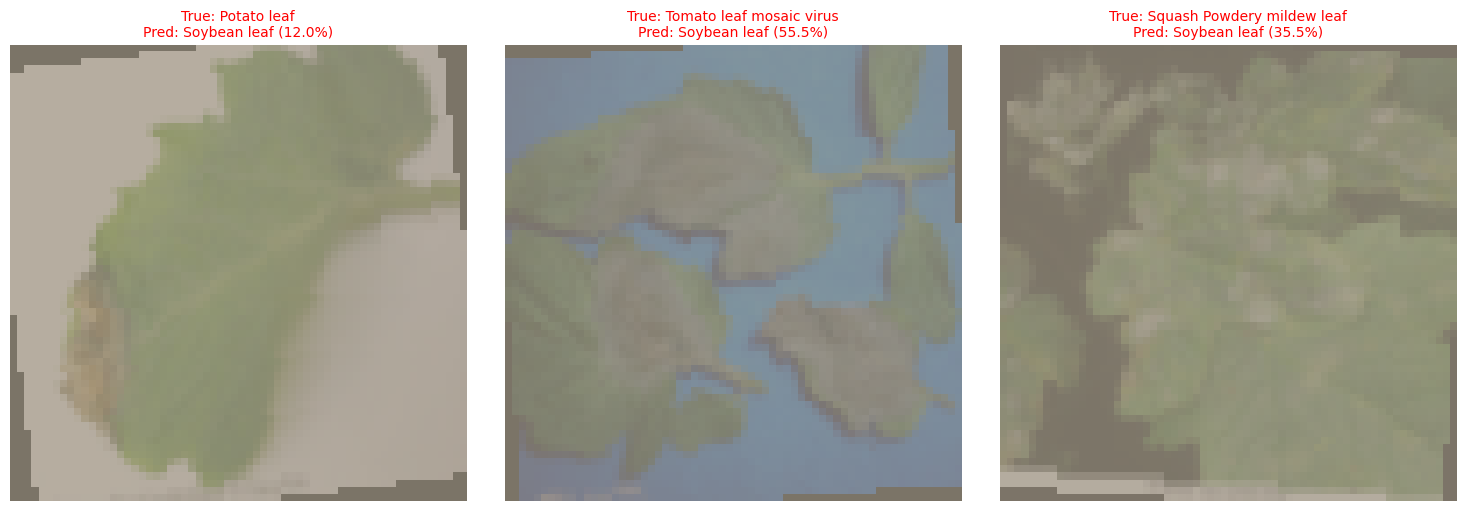

In [68]:
def plot_three_predictions(model, dataset, class_names_list, device):
    model.eval()

    # Create a layout with 1 row and 3 columns
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    # ImageNet stats for exact color restoration
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])

    for i in range(3):
        random_idx = random.randint(0, len(dataset) - 1)
        image_tensor, true_label = dataset[random_idx]

        with torch.inference_mode():
            pred_logits = model(image_tensor.unsqueeze(0).to(device))
            pred_prob = torch.softmax(pred_logits, dim=1)
            pred_label = torch.argmax(pred_prob, dim=1).item()

        # Fix color channel alignment and denormalize
        img_to_show = image_tensor.permute(1, 2, 0).cpu().numpy()
        img_to_show = std * img_to_show + mean
        img_to_show = np.clip(img_to_show, 0, 1)

        # Plot on the specific subplot axis
        axes[i].imshow(img_to_show)
        axes[i].axis("off")

        title_color = "green" if pred_label == true_label else "red"
        true_name = class_names_list[true_label]
        pred_name = class_names_list[pred_label]

        axes[i].set_title(
            f"True: {true_name}\nPred: {pred_name} ({pred_prob[0][pred_label].item()*100:.1f}%)",
            color=title_color,
            fontsize=10,
        )

    plt.tight_layout()
    plt.show()


# Run it!
plot_three_predictions(
    model=model_efficientnet,
    dataset=doc_test_data,
    class_names_list=find_class_names_doc(),
    device=device,
)

In [63]:
#model_save_path = "models/efficientnet_b0_plant_disease_38_class.pth"
#torch.save(model_efficientnet.state_dict(), model_save_path)

#print(f"🎉 Model weights successfully saved to: {model_save_path}")

🎉 Model weights successfully saved to: models/efficientnet_b0_plant_disease_38_class.pth


# Species identification

## Getting the data 

In [ ]:
# os.environ["KAGGLEHUB_CACHE"] = str(Path("").absolute() / "leafsnap_data")

# 2. Run the download (it will go straight into the folder above)
# path = kagglehub.dataset_download("vandat2601/leafsnap-processed")
# print("Downloaded straight to:", path)

# 3. See what folders are inside it
# print("\nContents of your local folder:")
# print(os.listdir(path))
#!pip install tqdm

In [ ]:
images, labels = next(iter(train_dataloader))

# 2. Set up a grid to plot
plt.figure(figsize=(10, 5))
for i in range(4):
    plt.subplot(1, 4, i + 1)

    # PyTorch images are [Channels, Height, Width], but matplotlib needs [Height, Width, Channels]
    # We use .permute() to swap the dimensions
    img = images[i].permute(1, 2, 0).numpy()

    plt.imshow(img)
    plt.title(f"Label: {labels[i].item()}")
    plt.axis("off")

plt.show()